In [1]:
# set wd
import os
from pathlib import Path
print(os.getcwd())
wd = Path(os.getcwd())
if wd.name == "notebooks":
    %cd ..
print(f"Working Dir Base: {(os.getcwd())}")

/Users/peli/Projects/Repositories/MEGPypes/notebooks
/Users/peli/Projects/Repositories/MEGPypes
Working Dir Base: /Users/peli/Projects/Repositories/MEGPypes


In [2]:
import yaml
import time
from bids.layout import BIDSLayout
# import
from megpypes.pipelines.meg_preprocessing import create_meg_preprocessing


/Users/peli/Projects/Repositories/MEGPypes/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded a MEG dataset from here:
https://openneuro.org/datasets/ds006629/versions/1.0.1

using datalad
```
datalad install -s https://github.com/OpenNeuroDatasets/ds006629.git data/ds006629
```
```
cd output/ds006629
datalad get -r .
```


First we need to grab data from our dataset.
We assume the data operate within a bids compliant data structure
https://peerherholz.github.io/workshop_weizmann/nipype/notebooks/basic_data_input_bids.html



In [3]:
# do some data inspection using pybids?
layout = BIDSLayout("data/ds006629/")
print(layout)
# subjects
subjects = layout.get_subjects()
print(f"Subjects: {subjects}")
# sessions
sessions = layout.get_sessions()
print(f"Sessions: {sessions}")
# task
layout.get_tasks()
# datatypes
bidstypes = layout.get_datatypes()
print(f"Data types: {bidstypes}")
# suffixes
print(layout.get_suffixes(datatype='func'))
# see tasks
layout.get_tasks()
print(f"Tasks: {layout.get_tasks()}")
# see dataset description
layout.get_dataset_description()
#

# see data metadata


BIDS Layout: ...itories/MEGPypes/data/ds006629 | Subjects: 19 | Sessions: 0 | Runs: 19
Subjects: ['01', '02', '04', '05', '06', '07', '08', '09', '10', '11', '12', '14', '15', '16', '17', '18', '19', '20', '21']
Sessions: []
Data types: ['meg']
[]
Tasks: ['MMNHCS', 'noise']


{'Name': 'SINGSING',
 'BIDSVersion': '1.7.0',
 'License': 'CC0',
 'DatasetType': 'raw',
 'Authors': ['Valerie Chanoine',
  'Jean-Michel Badier',
  'Mireille Besson',
  'Talya Inbar'],
 'Acknowledgements': 'MEG data acquisition was performed in the MEG Centre (Timone Hospital, Marseille, France)',
 'Funding': ['This research has been supported by funding from the Institute of Convergence ILCB (France 2030, ANR-16-CONV-0002) and the Excellence Initiative of Aix-Marseille University A*MIDEX (ANR-11-IDEX-0001-02)'],
 'ReferencesAndLinks': ['a data paper',
  'a resource to be cited when using the data'],
 'DatasetDOI': 'doi:10.18112/openneuro.ds006629.v1.0.1',
 'GeneratedBy': [{'Name': 'MNE-BIDS',
   'Version': '0.14',
   'Description': 'MNE-BIDS is a Python package that allows you to read and write BIDS-compatible datasets with the help of MNE-Python.'}],
 'SourceDatasets': [{'DOI': 'doi:10.18112/openneuro.ds006629.v1.0.0',
   'URL': 'https://openneuro.org/datasets/ds006629',
   'Version':

raw_dir /Users/peli/Projects/Repositories/MEGPypes/data/effort
Iterating over fields: ['subject', 'session']
Provided iterable values: {'subject': ['0001'], 'session': ['01', '02']}
Processing iterable field: subject
Using custom values for field: subject
Processing iterable field: session
Using custom values for field: session
Final iterables dict: {'subject': ['0001'], 'session': ['01', '02']}
260316-21:45:03,159 nipype.workflow DEBUG:
	 (megpreproc.infosource, megpreproc.selectfiles): No edge data
260316-21:45:03,159 nipype.workflow DEBUG:
	 (megpreproc.infosource, megpreproc.selectfiles): new edge data: {'connect': [('subject', 'subject')]}
260316-21:45:03,160 nipype.workflow DEBUG:
	 (megpreproc.infosource, megpreproc.selectfiles): Edge data exists: {'connect': [('subject', 'subject')]}
260316-21:45:03,160 nipype.workflow DEBUG:
	 (megpreproc.infosource, megpreproc.selectfiles): new edge data: {'connect': [('subject', 'subject'), ('session', 'session')]}
Valid inputs for initial_p

/Users/peli/Projects/Repositories/MEGPypes/.venv/lib/python3.13/site-packages/nipype/external/cloghandler.py:145: UserWarning: The given 'filename' should be an absolute path.  If your application calls os.chdir(), your logs may get messed up. Use 'supress_abs_warn=True' to hide this message.
  warn(


260316-21:45:03,383 nipype.workflow INFO:
	 Generated workflow graph: workdir/megpreproc/graph.png (graph2use=colored, simple_form=True).
Workflow graph saved to: workdir/megpreproc/graph.png
Running with 8 workers
260316-21:45:03,386 nipype.workflow DEBUG:
	 Creating flat graph for workflow: megpreproc
260316-21:45:03,387 nipype.workflow DEBUG:
	 expanding workflow: megpreproc
260316-21:45:03,388 nipype.workflow DEBUG:
	 processing node: megpreproc.infosource
260316-21:45:03,388 nipype.workflow DEBUG:
	 processing node: megpreproc.selectfiles
260316-21:45:03,388 nipype.workflow DEBUG:
	 processing node: megpreproc.initial_preproc
260316-21:45:03,389 nipype.workflow DEBUG:
	 processing node: megpreproc.artifact_rejection
260316-21:45:03,389 nipype.workflow DEBUG:
	 processing node: megpreproc.datasink
260316-21:45:03,389 nipype.workflow DEBUG:
	 processing node: megpreproc.epoching
260316-21:45:03,389 nipype.workflow DEBUG:
	 processing node: megpreproc.collect_epochs
260316-21:45:03,3

2026-03-16 21:45:03,425 [INFO] megpypes.interfaces.initpreproc: WF: Initial Preproc | In-File: /Users/peli/Projects/Repositories/MEGPypes/data/effort/0001_effortlearning_20250805_01.ds/0001_effortlearning_20250805_01.meg4


ds directory : /Users/peli/Projects/Repositories/MEGPypes/data/effort/0001_effortlearning_20250805_01.ds
    res4 data read.
    hc data read.
    Separate EEG position data file read.
    Quaternion matching (desired vs. transformed):
      -0.30   68.13    0.00 mm <->   -0.30   68.13   -0.00 mm (orig :  -44.05   52.70 -261.58 mm) diff =    0.000 mm
       0.30  -68.13    0.00 mm <->    0.30  -68.13   -0.00 mm (orig :   52.69  -43.26 -262.62 mm) diff =    0.000 mm
      91.72    0.00    0.00 mm <->   91.72   -0.00    0.00 mm (orig :   67.41   67.51 -239.98 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    64 EEG electrode locations assigned to channel info.
    64 EEG locations added to Polhemus data.
    Measurement info composed.
Finding samples for /Users/peli/Projects/Repositories/MEGPypes/data/effort/0001_effortlearning_20250805_01.ds/0001_effortlearning_20250805_01.

...

260316-21:46:13,819 nipype.workflow INFO:
	 [Node] Finished "epoching", elapsed time 2.355112s.
260316-21:46:13,819 nipype.workflow DEBUG:
	 Needed files: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_4_event_label_force_start_event_tmax_5.0_event_tmin_-0.5/epoching/force_start_epoched-epo.fif;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_4_event_label_force_start_event_tmax_5.0_event_tmin_-0.5/epoching/_0x2d5c75ca7e3a08d0addb617719f0829a_unfinished.json;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_4_event_label_force_start_event_tmax_5.0_event_tmin_-0.5/epoching/_inputs.pklz;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_4_event_label_force_start_event_tmax_5.0_event_tmin_-0.5/epoching/_node.pklz
260316-21:46:13,819 nipype.workflow DEBUG:
	 Needed dirs: /Users/peli/Projects/Repositori

2026-03-16 21:46:13,827 [INFO] megpypes.interfaces.epoching: NODE: Epoching | In-File: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/artifact_rejection/artifact_cleaned_raw.fif
2026-03-16 21:46:13,827 [INFO] megpypes.interfaces.epoching: Epoching for event: feedback_onset
2026-03-16 21:46:13,827 [INFO] megpypes.interfaces.epoching: id: 8, tmin: -1.0, tmax: 1.5


Opening raw data file /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/artifact_rejection/artifact_cleaned_raw.fif...
    Read 5 compensation matrices
    Range : 6460 ... 752702 =      5.513 ...   642.306 secs
Ready.
Current compensation grade : 0
Reading 0 ... 746242  =      0.000 ...   636.793 secs...
Finding events on: UDIO001
582 events found on stim channel UDIO001
Event IDs: [   1    2    4    6    7    8   10   13   16   19   22   30   50   55
 1024 2048 2059 2062 2065 4096]
Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 40 events and 2931 original time points ...
0 bad epochs dropped


2026-03-16 21:46:15,383 [INFO] megpypes.interfaces.epoching: OUT FILE PATH: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_8_event_label_feedback_onset_event_tmax_1.5_event_tmin_-1.0/epoching/feedback_onset_epoched-epo.fif
2026-03-16 21:46:15,506 [INFO] megpypes.interfaces.epoching: Saved: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_8_event_label_feedback_onset_event_tmax_1.5_event_tmin_-1.0/epoching/feedback_onset_epoched-epo.fif


260316-21:46:15,507 nipype.workflow INFO:
	 [Node] Finished "epoching", elapsed time 1.679904s.
260316-21:46:15,507 nipype.workflow DEBUG:
	 Needed files: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_8_event_label_feedback_onset_event_tmax_1.5_event_tmin_-1.0/epoching/feedback_onset_epoched-epo.fif;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_8_event_label_feedback_onset_event_tmax_1.5_event_tmin_-1.0/epoching/_0xa8a8bde6539367f1d81b8053638488d0_unfinished.json;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_8_event_label_feedback_onset_event_tmax_1.5_event_tmin_-1.0/epoching/_inputs.pklz;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_02_subject_0001/_event_id_8_event_label_feedback_onset_event_tmax_1.5_event_tmin_-1.0/epoching/_node.pklz
260316-21:46:15,508 nipype.workflow DEBUG:
	 Needed dirs: /Users/peli/Proj

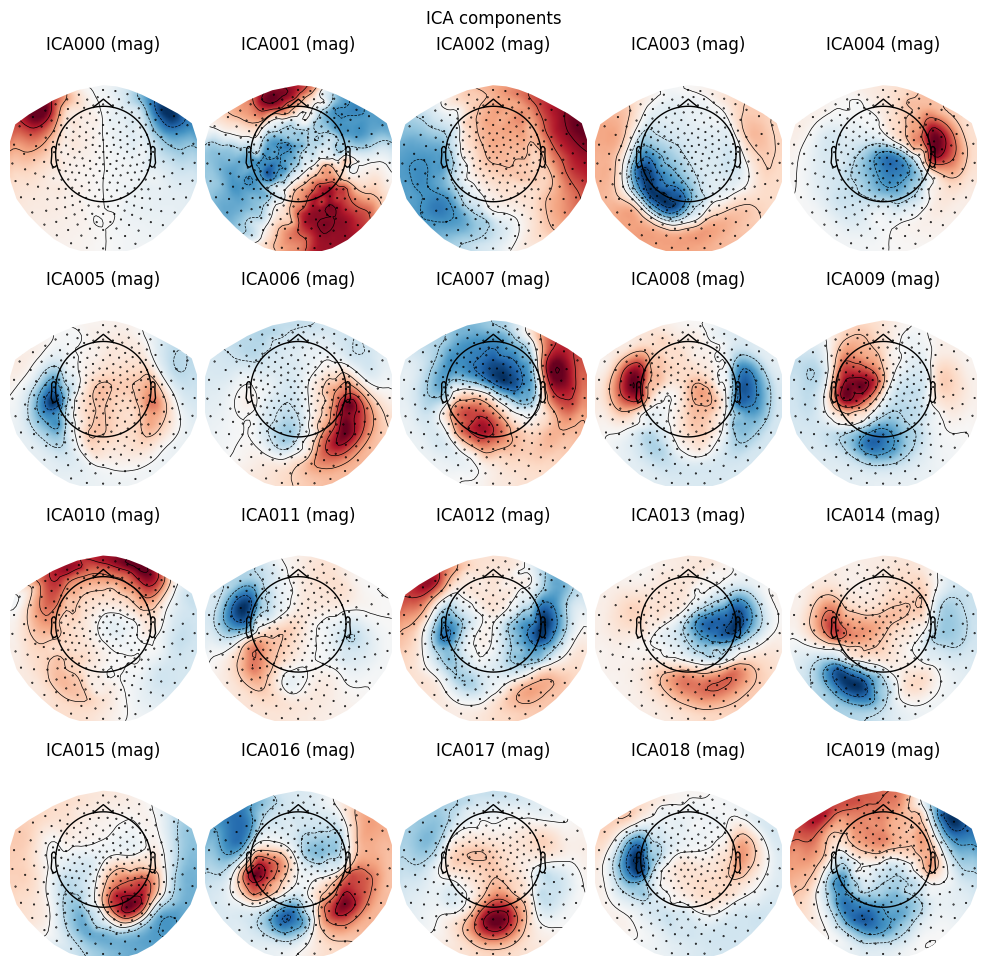

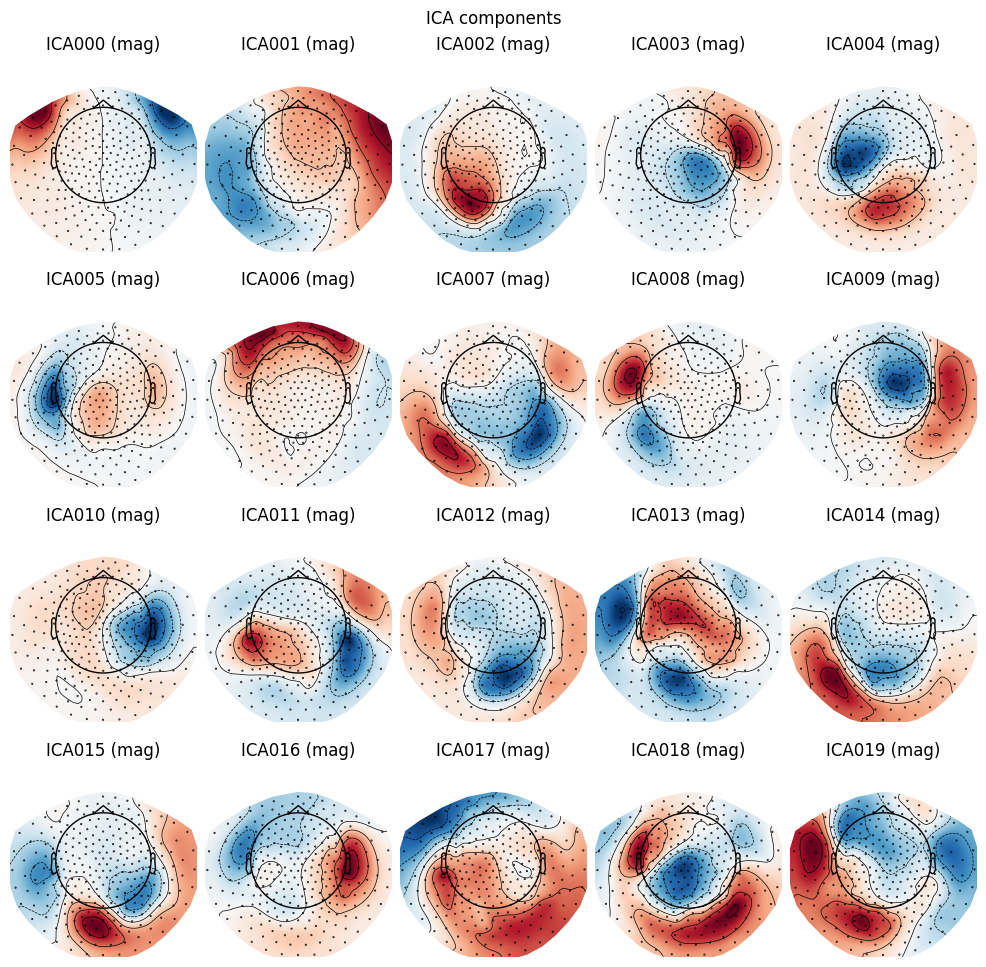

In [4]:
# Load configs
import os
import yaml
from nipype import config as nconfig
from nipype import logging

config_path = "config/config_effort.yaml"
with open(config_path, "r") as yamlfile:
    config = yaml.load(yamlfile, Loader=yaml.FullLoader)

wf_config = config['workflow']
paths_config = config['paths']

# Configure Nipype logging (applies to all subprocesses)
logs_dir = Path(paths_config["workdir"]) / 'logs'
logs_dir.mkdir(parents=True, exist_ok=True)
config_dict = {
    'logging': {
        'log_directory': logs_dir,
        'log_to_file': True,
        'interface_level': 'DEBUG',
        'workflow_level': 'DEBUG',
    },
    'execution': {
        'crashdump_dir': os.path.abspath('crashes'),
        'remove_unnecessary_outputs': False,
    }
}
nconfig.update_config(config_dict)
logging.update_logging(nconfig)

# Create workflow
wf = create_meg_preprocessing(
    basedir=paths_config['basedir'], 
    workdir=paths_config['workdir'], 
    output_dir=paths_config['outputdir'],
    file_templates=paths_config.get('file_templates', None),
    iterable_fields=paths_config.get('iterable_fields', None),
    iterable_values=paths_config.get('iterable_values', None),
    pipeline_config=config['pipeline_config']
    )

# visualize workflow graph
wf.write_graph(graph2use='colored', simple_form=True)
print(f"Workflow graph saved to: {wf.base_dir}/megpreproc/graph.png")

# Run workflow
n_workers = wf_config.get("n_workers", max(1, os.cpu_count() - 2))
print(f"Running with {n_workers} workers")

result = wf.run(
    plugin=wf_config["plugin"],
    plugin_args={"n_procs": n_workers}
)